In [1]:
from google.colab import files
from IPython.display import Image
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
uploaded = files.upload()

Saving minion.jpg to minion.jpg


In [3]:
filename = list(uploaded.keys())[0]

img = cv2.imread(filename)
print("Loaded:", filename, "-> shape:", img.shape)

Loaded: minion.jpg -> shape: (200, 240, 3)


In [4]:
def show_images(images, titles):
    plt.figure(figsize=(12,5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis("off")
    plt.show()

The show_images function is a helper designed to display multiple images side by side using Matplotlib. It takes two lists as input: one containing the images to display and another containing their corresponding titles. The function first sets the figure size to make the display wide enough for all images. Then, it loops through each image, creating a subplot for each one, converting it from OpenCV’s default BGR color format to RGB so that colors appear correctly, and assigning the appropriate title. The axes are turned off for a cleaner appearance, and finally plt.show() renders all the images in a single row, allowing for easy visual comparison of the results.

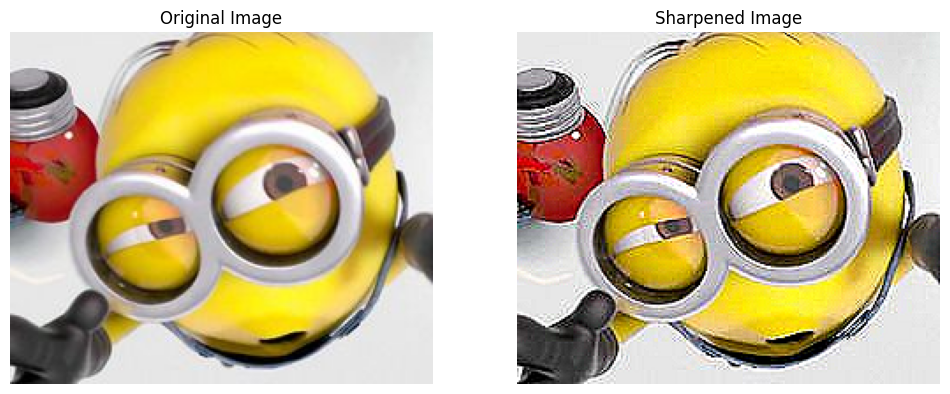

In [5]:
# SHARPENED

sharpen_kernel = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

sharpened = cv2.filter2D(img, -1, sharpen_kernel)

show_images([img, sharpened], ["Original Image", "Sharpened Image"])


In this code, a sharpening kernel is defined as a 3×3 matrix that enhances edges by increasing the intensity of the center pixel while subtracting the values of its neighbors. The cv2.filter2D function applies this kernel to the original image img, producing sharpened, which appears crisper and more defined.

The center value (5): Much larger than the other coefficients, it means the current pixel’s intensity is strongly preserved.

The -1 values around: These subtract contributions from the immediate neighbors (up, down, left, right). This emphasizes differences between the center pixel and its surroundings. If the pixel is similar to its neighbors, the result won’t change much. If the pixel is different (like at an edge), the difference gets amplified.

The 0 values in the corners: Mean the diagonal neighbors are ignored in this sharpening process. The focus is only on the 4 main directions (N, S, E, W).

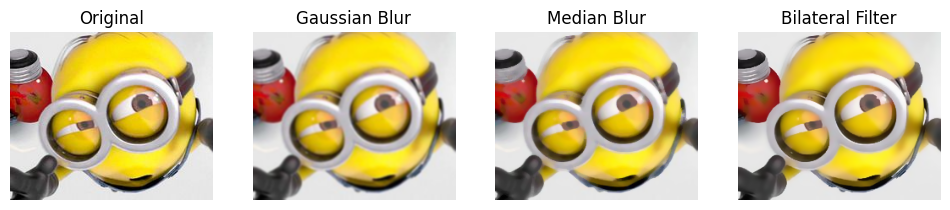

In [6]:
# BLUR

# Gaussian Blur
gaussian = cv2.GaussianBlur(img, (5,5), 0)

# Median Blur
median = cv2.medianBlur(img, 5)

# Bilateral Filter
bilateral = cv2.bilateralFilter(img, d=9, sigmaColor=75, sigmaSpace=75)

show_images([img, gaussian, median, bilateral],
            ["Original", "Gaussian Blur", "Median Blur", "Bilateral Filter"])

This code applies three different noise reduction techniques to the original image. First, a Gaussian Blur smooths the image by averaging nearby pixels, which reduces general noise but can slightly blur edges. Second, a Median Blur replaces each pixel with the median of its neighbors, which is particularly effective at removing “salt-and-pepper” noise while preserving edges. Third, a Bilateral Filter reduces noise while keeping edges sharp by considering both spatial proximity and color similarity.

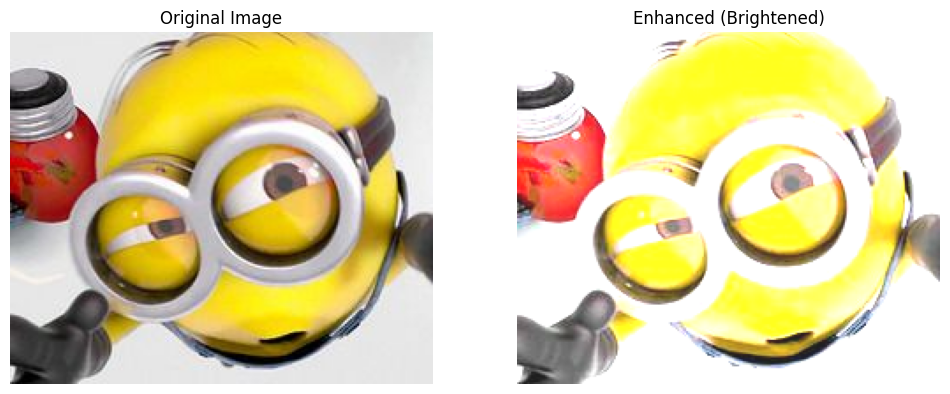

In [7]:
# BRIGHTENED

brightened = cv2.convertScaleAbs(img, alpha=1.5, beta=30)

show_images([img, brightened], ["Original Image", "Enhanced (Brightened)"])

In this code, the original image is enhanced in brightness and contrast using cv2.convertScaleAbs. The parameter alpha=1.5 increases the contrast by scaling the pixel values, while beta=30 increases the brightness by adding a constant value to each pixel. The result is stored in brightened, which appears more vivid and visually appealing.

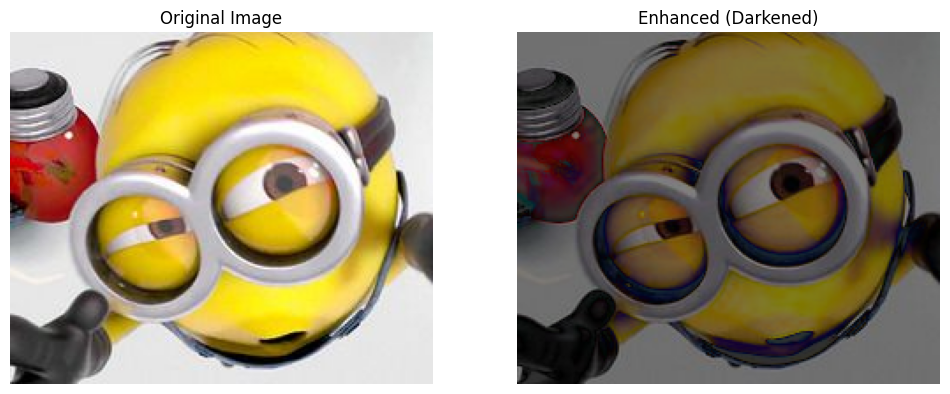

In [8]:
#DARKENED

darkened = cv2.convertScaleAbs(img, alpha=0.7, beta=-50)

show_images([img, darkened], ["Original Image", "Enhanced (Darkened)"])


Here in this code, the original image is adjusted to appear darker using cv2.convertScaleAbs. The parameter alpha=0.7 reduces the contrast by scaling down the pixel values, while beta=-50 decreases the brightness by subtracting a constant value from each pixel. The resulting image, stored in darkened, appears dimmer and less intense than the original.

In [9]:
import matplotlib.pyplot as plt

def show_before_after(before, after, title_before="Before", title_after="After"):
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(before, cv2.COLOR_BGR2RGB))
    plt.title(title_before)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(after, cv2.COLOR_BGR2RGB))
    plt.title(title_after)
    plt.axis("off")

    plt.show()


The show_before_after function is a helper designed to display two images side by side for easy comparison. It takes a before image and an after image as input, along with optional titles. The function creates a figure with Matplotlib and splits it into two subplots: the first shows the original image, and the second shows the processed image. Each image is converted from OpenCV’s default BGR color format to RGB so that colors display correctly, and the axes are turned off for a cleaner appearance.

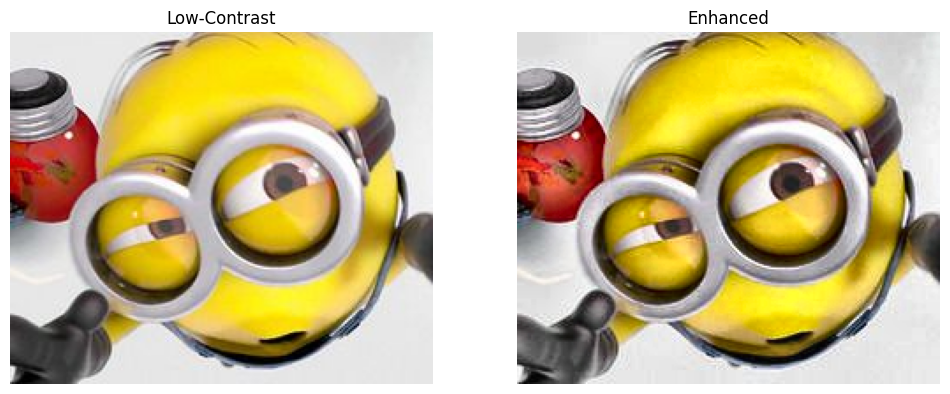

In [10]:
# CONTRAST

lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l2 = clahe.apply(l)
lab = cv2.merge((l2,a,b))
contrast_enhanced = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

show_before_after(img, contrast_enhanced, "Low-Contrast", "Enhanced")


In this code, the image’s contrast is enhanced using CLAHE (Contrast Limited Adaptive Histogram Equalization). First, the image is converted from BGR to LAB color space, which separates lightness (L) from color channels (A and B). The L-channel, representing brightness, is extracted and processed with CLAHE to improve local contrast without affecting colors. The modified L-channel is then merged back with the original A and B channels, and the image is converted back to BGR format. The result, stored in contrast_enhanced, has improved visibility and more pronounced details in darker or flatter areas.

In [11]:
def add_salt_pepper_noise(image, amount=0.02):
    noisy = image.copy()
    num_salt = np.ceil(amount * image.size * 0.5).astype(int)
    num_pepper = np.ceil(amount * image.size * 0.5).astype(int)

    # Salt (white pixels)
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape[:2]]
    noisy[coords[0], coords[1], :] = 255

    # Pepper (black pixels)
    coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape[:2]]
    noisy[coords[0], coords[1], :] = 0

    return noisy


The add_salt_pepper_noise function introduces salt-and-pepper noise into an image, creating random white and black pixels that simulate common image noise. It first makes a copy of the original image to avoid modifying it directly. The number of white (“salt”) and black (“pepper”) pixels is calculated based on the amount parameter, which determines the noise intensity. Random coordinates are generated for each type of noise, and the corresponding pixels are set to 255 (white) for salt or 0 (black) for pepper. The resulting image, noisy, contains these scattered bright and dark spots, making it useful for testing noise removal techniques.

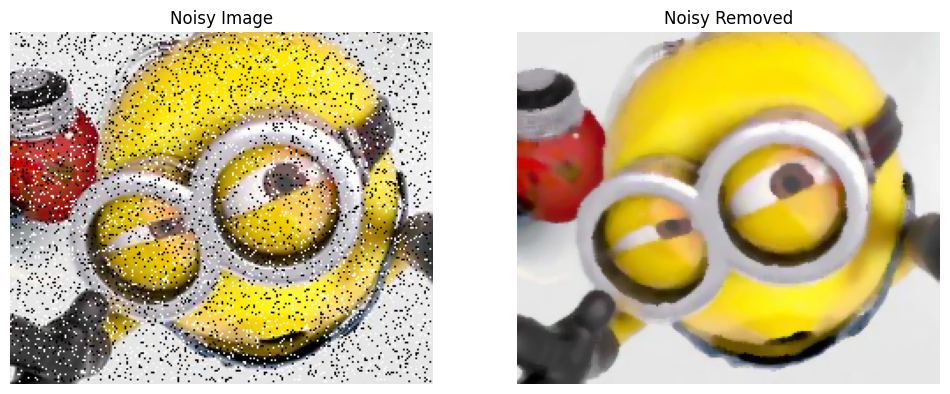

In [12]:
# NOISY

noisy_img = add_salt_pepper_noise(img, amount=0.05)

removal = cv2.medianBlur(noisy_img, 5)

show_images([noisy_img, removal],
            ["Noisy Image", "Noisy Removed"])

Salt-and-pepper noise is first added to the original image using the add_salt_pepper_noise function with an intensity of 5%, creating noisy_img that contains random white and black pixels. To reduce this noise, a Median Blur filter is applied, which replaces each pixel with the median value of its surrounding neighbors, effectively removing the scattered noise while preserving edges. Finally

(np.float64(-0.5), np.float64(239.5), np.float64(199.5), np.float64(-0.5))

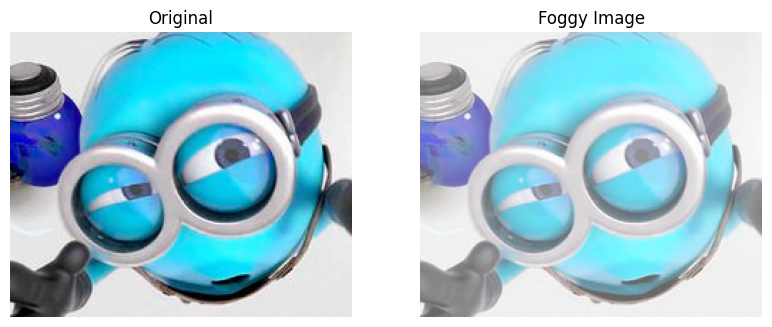

In [13]:
#FOGGY

foggy = cv2.addWeighted(img, 0.6, np.full_like(img, 255), 0.4, 0)

lab = cv2.cvtColor(foggy, cv2.COLOR_RGB2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
cl = clahe.apply(l)

enhanced_lab = cv2.merge((cl,a,b))
enhanced = cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2RGB)

plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(foggy)
plt.title("Foggy Image")
plt.axis("off")

This code creates a foggy effect by blending the original image with white using cv2.addWeighted(), making it look hazy. The foggy image is then converted to LAB color space so that the lightness (L) channel can be enhanced separately using CLAHE, which improves local contrast without distorting colors. After enhancement, the channels are merged back and converted to RGB, producing a clearer image. Finally, the original, foggy, and enhanced images are displayed side by side.

Notes:

The reason the code uses multiple small functions, like show_images, show_before_after, and add_salt_pepper_noise, instead of combining everything into one big function, is mainly for clarity, modularity, and reusability. Each function is responsible for a single task, which makes it easy to reuse in different parts of the code, improves readability, and simplifies debugging because you know exactly where to look if something goes wrong. This approach also provides flexibility, allowing you to mix and match steps, such as displaying images, comparing before and after, or adding and removing noise, without running the entire pipeline each time. Additionally, maintaining or updating one function, for example changing how images are displayed, does not affect the rest of the code. Overall, using multiple small functions keeps the code cleaner, easier to understand, and more manageable, whereas a single large function could become complex and harder to debug.